In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
from google.colab import files
uploaded = files.upload()

Saving dar.png.jpeg to dar.png.jpeg


In [13]:
from PIL import Image

img = Image.open("dar.png.jpeg").convert("RGB")

In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

In [16]:
# Load model
model = ResNet50(weights="imagenet")


In [17]:
# Resize image
img_resized = img.resize((224, 224))
img_array = np.array(img_resized)

In [18]:
# Prepare input
img_batch = np.expand_dims(img_array, axis=0)
img_batch = preprocess_input(img_batch)

In [19]:
# Predict
predictions = model.predict(img_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [20]:
# Decode results
decoded = decode_predictions(predictions, top=5)[0]


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


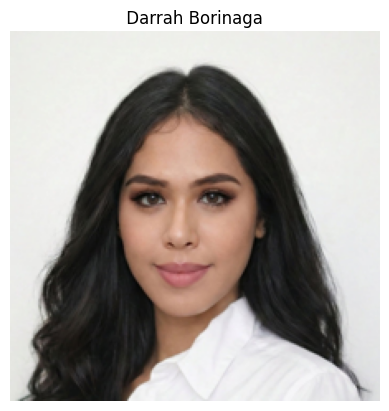

In [23]:
# Show image
plt.imshow(img_resized)
plt.title(" Darrah Borinaga ")
plt.axis("off")
plt.show()


In [22]:
# Print predictions
print("\nTop-5 Predictions:")
print("-" * 40)
for i, pred in enumerate(decoded):
    print(f"{i+1}. {pred[1]} ({pred[2]*100:.2f}%)")


Top-5 Predictions:
----------------------------------------
1. jersey (11.51%)
2. brassiere (7.03%)
3. wig (5.21%)
4. jean (4.83%)
5. lab_coat (4.20%)


#  Analysis of Model Predictions

## Overview
The pretrained ResNet50 model was applied to a personal portrait image to evaluate how it interprets human facial features using ImageNet-trained object categories.

## Top-5 Predictions

1. jersey (11.51%)
2. brassiere (7.03%)
3. wig (5.21%)
4. jean (4.83%)
5. lab_coat (4.20%)

---

## Interpretation of Results

The model did not produce a single dominant prediction, as all confidence scores remained relatively low (<12%). This indicates that the model is uncertain and unable to strongly associate the input image with a specific ImageNet class.

### Key Observations

- The predictions are primarily related to **clothing categories** (jersey, brassiere, jean, lab coat).
- The presence of the "wig" class suggests the model is detecting **hair-related visual patterns**, such as smooth texture and symmetry.
- The model is attempting to map facial and upper-body features to the closest known categories within its training dataset.

---

## Model Behavior Analysis

This outcome highlights a key limitation of pretrained CNN models:

> ResNet50 is trained on object categories, not human identities or facial understanding.

As a result:
- The model interprets the image based on **visual similarity**, not semantic meaning.
- It focuses on:
  - textures (hair, fabric)
  - shapes (face structure, shoulders)
  - color patterns

---

## Confidence Analysis

All predicted probabilities are relatively low, with the highest being only 11.51%.

This suggests:
- The model is **uncertain**
- The image does not strongly match any specific ImageNet category
- Multiple classes share similar feature representations

---

## Conclusion

The results demonstrate that while ResNet50 can extract meaningful visual features from a human portrait, it is not designed to accurately classify or understand human faces.

Instead, it approximates the input image by matching it to the closest object-based categories, resulting in low-confidence and semantically indirect predictions.

This experiment reinforces the importance of:
- domain-specific training (e.g., face recognition models)
- appropriate dataset selection
- understanding model limitations in real-world applications

In [24]:
from PIL import ImageEnhance

# Brightness
enhancer = ImageEnhance.Brightness(img)
img_bright = enhancer.enhance(1.3)

# Contrast
enhancer = ImageEnhance.Contrast(img)
img_contrast = enhancer.enhance(1.5)

# Sharpness
enhancer = ImageEnhance.Sharpness(img)
img_sharp = enhancer.enhance(2.0)

In [25]:
def predict_image(image, title):
    img_resized = image.resize((224, 224))
    img_array = np.array(img_resized)

    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = preprocess_input(img_batch)

    pred = model.predict(img_batch)
    decoded = decode_predictions(pred, top=3)[0]

    print(f"\n{title}")
    print("-" * 40)
    for i, p in enumerate(decoded):
        print(f"{i+1}. {p[1]} ({p[2]*100:.2f}%)")

    plt.imshow(img_resized)
    plt.title(title)
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step

Original
----------------------------------------
1. jersey (11.51%)
2. brassiere (7.03%)
3. wig (5.21%)


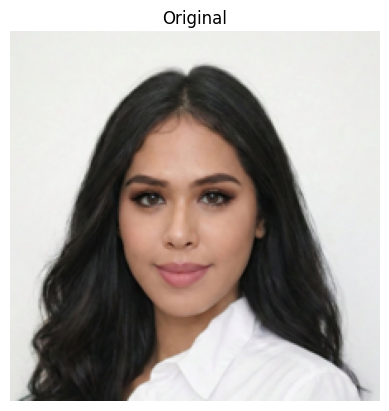

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

Brightness Enhanced
----------------------------------------
1. brassiere (14.49%)
2. jersey (13.20%)
3. maillot (8.42%)


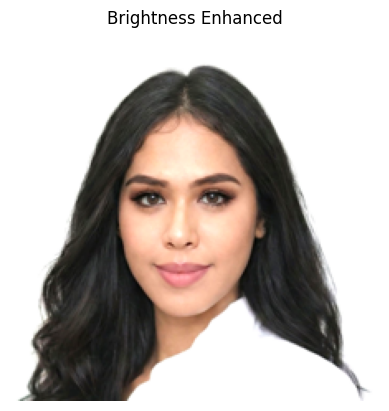

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step

Contrast Enhanced
----------------------------------------
1. jersey (14.27%)
2. brassiere (9.90%)
3. abaya (6.13%)


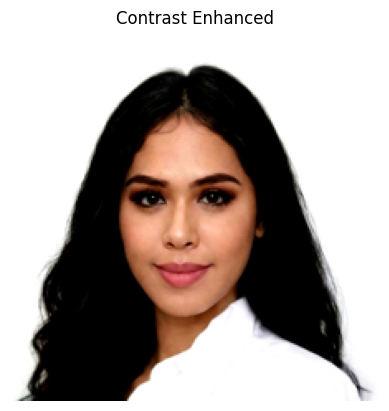

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step

Sharpness Enhanced
----------------------------------------
1. jersey (11.45%)
2. brassiere (7.04%)
3. wig (5.17%)


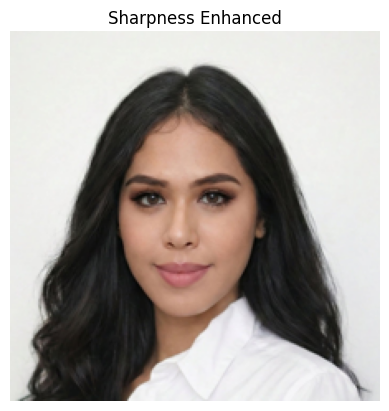

In [26]:
predict_image(img, "Original")
predict_image(img_bright, "Brightness Enhanced")
predict_image(img_contrast, "Contrast Enhanced")
predict_image(img_sharp, "Sharpness Enhanced")

In [27]:
import pandas as pd

results = []

def collect_predictions(image, label):
    img_resized = image.resize((224, 224))
    img_array = np.array(img_resized)

    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = preprocess_input(img_batch)

    pred = model.predict(img_batch)
    decoded = decode_predictions(pred, top=1)[0][0]

    results.append({
        "Image Type": label,
        "Prediction": decoded[1],
        "Confidence (%)": round(decoded[2]*100, 2)
    })

# Collect results
collect_predictions(img, "Original")
collect_predictions(img_bright, "Bright")
collect_predictions(img_contrast, "Contrast")
collect_predictions(img_sharp, "Sharp")

df = pd.DataFrame(results)
df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


,Image Type,Prediction,Confidence (%)
0,Original,jersey,11.51
1,Bright,brassiere,14.49
2,Contrast,jersey,14.27
3,Sharp,jersey,11.45


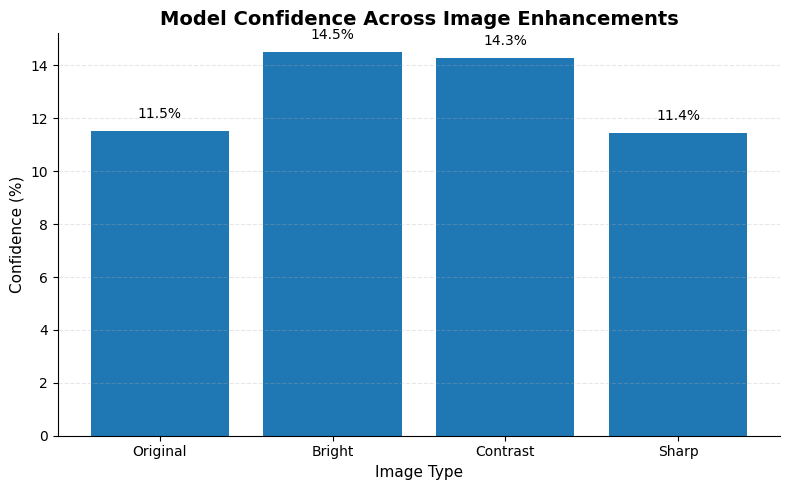

In [38]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8,5))

# Plot
bars = plt.bar(df["Image Type"], df["Confidence (%)"])

# Titles
plt.title("Model Confidence Across Image Enhancements", fontsize=14, weight='bold')
plt.xlabel("Image Type", fontsize=11)
plt.ylabel("Confidence (%)", fontsize=11)

# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        fontsize=10
    )

# Grid (subtle)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
import tensorflow as tf
import numpy as np
import cv2

def get_gradcam(image, model, layer_name="conv5_block3_out"):
    img_resized = image.resize((224, 224))
    img_array = np.array(img_resized)
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = preprocess_input(img_batch)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)
        loss = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap, img_resized

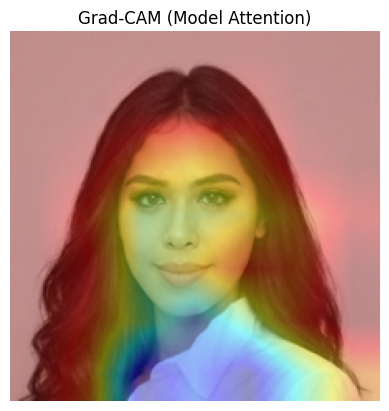

In [34]:
heatmap, base_img = get_gradcam(img, model)

heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(np.array(base_img), 0.6, heatmap, 0.4, 0)

plt.figure()
plt.imshow(superimposed)
plt.title("Grad-CAM (Model Attention)")
plt.axis("off")
plt.show()